In [1]:
#1.Import Libraries

In [2]:
import pandas as pd
import numpy as np
import time
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [3]:
#2.Split & Scale Function

In [4]:
def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size=0.25, random_state=0)
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)
    return X_train, X_test, y_train, y_test

In [5]:
#3.R² Prediction Function

In [6]:
def r2_prediction(regressor, X_test, y_test):
    y_pred = regressor.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2

In [7]:
#4.Regression Model Functions

In [8]:
def Linear(X_train, y_train, X_test):
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)
    return r2_prediction(regressor, X_test, y_test)

def svm_linear(X_train, y_train, X_test):
    regressor = SVR(kernel='linear')
    regressor.fit(X_train, y_train)
    return r2_prediction(regressor, X_test, y_test)

def svm_NL(X_train, y_train, X_test):
    regressor = SVR(kernel='rbf')
    regressor.fit(X_train, y_train)
    return r2_prediction(regressor, X_test, y_test)

def Decision(X_train, y_train, X_test):
    regressor = DecisionTreeRegressor(random_state=0)
    regressor.fit(X_train, y_train)
    return r2_prediction(regressor, X_test, y_test)

def random(X_train, y_train, X_test):
    regressor = RandomForestRegressor(n_estimators=10, random_state=0)
    regressor.fit(X_train, y_train)
    return r2_prediction(regressor, X_test, y_test)

In [9]:
#5.RFE Feature Selection Function

In [10]:
def rfeFeature(indep_X, dep_Y, n):
    rfelist = []
    # scale only for RFE ranking (faster convergence for linear models / SVR)
    X_scaled = StandardScaler().fit_transform(indep_X)
    lin = LinearRegression()
    SVRl = SVR(kernel='linear')
    dec = DecisionTreeRegressor(random_state=0)
    rf = RandomForestRegressor(n_estimators=10, random_state=0)
    rfemodellist = [lin, SVRl, dec, rf]
    for i in rfemodellist:
        print(i)
        log_rfe = RFE(estimator=i, n_features_to_select=n)
        log_fit = log_rfe.fit(X_scaled, dep_Y)
        print('  Selected features:', list(indep_X.columns[log_fit.support_]))
        log_rfe_feature = indep_X.loc[:, log_fit.support_].values  # original (unscaled) selected columns
        rfelist.append(log_rfe_feature)
    return rfelist

In [11]:
#6.Result Table Function

In [12]:
def rfe_regression(acclin, accsvml, accsvmnl, accdes, accrf):
    # row order matches rfemodellist = [lin, SVRl, dec, rf]
    rfedataframe = pd.DataFrame(index=['Linear', 'SVRl', 'DecisionTree', 'Random'],
                                columns=['Linear', 'SVMl', 'SVMnl', 'Decision', 'Random'])
    for number, idex in enumerate(rfedataframe.index):
        rfedataframe.loc[idex, 'Linear'] = acclin[number]
        rfedataframe.loc[idex, 'SVMl'] = accsvml[number]
        rfedataframe.loc[idex, 'SVMnl'] = accsvmnl[number]
        rfedataframe.loc[idex, 'Decision'] = accdes[number]
        rfedataframe.loc[idex, 'Random'] = accrf[number]
    return rfedataframe.astype(float)

In [13]:
# LOAD DATA

In [14]:
dataset1 = pd.read_csv("prep.csv", index_col=None)
df2 = dataset1
df2 = pd.get_dummies(df2, drop_first=True)
df2.head()

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.0,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,False,False,False,False,False,False,True,True,False,True
1,3.0,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,True,False,False,False,False,False,True,False,False,True
2,4.0,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,True,False,False,False,False,False,True,False,False,True
3,5.0,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,True,False,False,False,False,False,True,False,True,True
4,5.0,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,True,False,False,False,False,False,True,False,False,True


In [15]:
indep_X = df2.drop('classification_yes', axis=1)
dep_Y = df2['classification_yes'].astype(int)
print(indep_X.shape, dep_Y.shape)

(399, 27) (399,)


In [16]:
#8.Run RFE (select top 3 features)

In [17]:
rfelist = rfeFeature(indep_X, dep_Y, 3)

LinearRegression()
  Selected features: ['hrmo', 'sg_c', 'sg_d']
SVR(kernel='linear')
  Selected features: ['hrmo', 'sg_c', 'sg_d']
DecisionTreeRegressor(random_state=0)
  Selected features: ['hrmo', 'sg_c', 'sg_d']
RandomForestRegressor(n_estimators=10, random_state=0)
  Selected features: ['al', 'hrmo', 'sg_d']


In [18]:
#9.Train All Regressors on Each RFE Feature Set

In [19]:
acclin = []
accsvml = []
accsvmnl = []
accdes = []
accrf = []

for i in rfelist:
    X_train, X_test, y_train, y_test = split_scalar(i, dep_Y)

    r2_lin = Linear(X_train, y_train, X_test)
    acclin.append(r2_lin)

    r2_sl = svm_linear(X_train, y_train, X_test)
    accsvml.append(r2_sl)

    r2_NL = svm_NL(X_train, y_train, X_test)
    accsvmnl.append(r2_NL)

    r2_d = Decision(X_train, y_train, X_test)
    accdes.append(r2_d)

    r2_r = random(X_train, y_train, X_test)
    accrf.append(r2_r)

In [20]:
#10.Result (rows = RFE selector, columns = regressor, values = R² score)

In [21]:
result = rfe_regression(acclin, accsvml, accsvmnl, accdes, accrf)
result

,Linear,SVMl,SVMnl,Decision,Random
Linear,0.664893,0.609652,0.883134,0.965961,0.916304
SVRl,0.664893,0.609652,0.883134,0.965961,0.916304
DecisionTree,0.664893,0.609652,0.883134,0.965961,0.916304
Random,0.676174,0.670691,0.900941,0.933504,0.887256


In [22]:
best = result.stack().idxmax()
print('Best combination -> RFE selector:', best[0], '| Regressor:', best[1], '| R2:', round(result.stack().max(), 4))

Best combination -> RFE selector: Linear | Regressor: Decision | R2: 0.966


In [23]:
#11.Compare Number of Features (n = 3, 5, 7, 10)

In [24]:
n_list = [3, 5, 7, 10]
all_results = {}

for n in n_list:
    print('\n================ n =', n, '================')
    rfelist = rfeFeature(indep_X, dep_Y, n)

    acclin, accsvml, accsvmnl, accdes, accrf = [], [], [], [], []
    for i in rfelist:
        X_train, X_test, y_train, y_test = split_scalar(i, dep_Y)
        acclin.append(Linear(X_train, y_train, X_test))
        accsvml.append(svm_linear(X_train, y_train, X_test))
        accsvmnl.append(svm_NL(X_train, y_train, X_test))
        accdes.append(Decision(X_train, y_train, X_test))
        accrf.append(random(X_train, y_train, X_test))

    all_results[n] = rfe_regression(acclin, accsvml, accsvmnl, accdes, accrf)
    display(all_results[n])


================ n = 3 ================
LinearRegression()
  Selected features: ['hrmo', 'sg_c', 'sg_d']
SVR(kernel='linear')
  Selected features: ['hrmo', 'sg_c', 'sg_d']
DecisionTreeRegressor(random_state=0)
  Selected features: ['hrmo', 'sg_c', 'sg_d']
RandomForestRegressor(n_estimators=10, random_state=0)
  Selected features: ['al', 'hrmo', 'sg_d']


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.664893,0.609652,0.883134,0.965961,0.916304
SVRl,0.664893,0.609652,0.883134,0.965961,0.916304
DecisionTree,0.664893,0.609652,0.883134,0.965961,0.916304
Random,0.676174,0.670691,0.900941,0.933504,0.887256



================ n = 5 ================
LinearRegression()
  Selected features: ['hrmo', 'sg_b', 'sg_c', 'sg_d', 'dm_yes']
SVR(kernel='linear')
  Selected features: ['hrmo', 'sg_c', 'sg_d', 'htn_yes', 'dm_yes']
DecisionTreeRegressor(random_state=0)
  Selected features: ['bu', 'hrmo', 'rc', 'sg_c', 'sg_d']
RandomForestRegressor(n_estimators=10, random_state=0)
  Selected features: ['al', 'hrmo', 'rc', 'sg_c', 'sg_d']


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.692984,0.667292,0.883806,0.960184,0.916207
SVRl,0.697491,0.669859,0.898582,0.964635,0.931181
DecisionTree,0.674403,0.628206,0.897334,0.696181,0.815538
Random,0.686361,0.643365,0.907120,0.836806,0.845303



================ n = 7 ================
LinearRegression()
  Selected features: ['al', 'hrmo', 'sg_b', 'sg_c', 'sg_d', 'htn_yes', 'dm_yes']
SVR(kernel='linear')
  Selected features: ['hrmo', 'pcv', 'sg_b', 'sg_c', 'sg_d', 'htn_yes', 'dm_yes']
DecisionTreeRegressor(random_state=0)
  Selected features: ['bu', 'hrmo', 'pcv', 'rc', 'sg_c', 'sg_d', 'htn_yes']
RandomForestRegressor(n_estimators=10, random_state=0)
  Selected features: ['al', 'hrmo', 'pcv', 'rc', 'sg_c', 'sg_d', 'dm_yes']


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.709926,0.679102,0.932369,0.974313,0.951871
SVRl,0.699769,0.681173,0.914439,0.924045,0.950163
DecisionTree,0.697704,0.666684,0.928844,0.913194,0.940972
Random,0.705879,0.667997,0.931111,0.797454,0.850957



================ n = 10 ================
LinearRegression()
  Selected features: ['al', 'bu', 'sc', 'hrmo', 'pcv', 'sg_b', 'sg_c', 'sg_d', 'htn_yes', 'dm_yes']
SVR(kernel='linear')
  Selected features: ['bu', 'sc', 'hrmo', 'pcv', 'sg_b', 'sg_c', 'sg_d', 'sg_e', 'htn_yes', 'dm_yes']
DecisionTreeRegressor(random_state=0)
  Selected features: ['bu', 'sc', 'hrmo', 'pcv', 'rc', 'sg_c', 'sg_d', 'htn_yes', 'pe_yes', 'ane_yes']
RandomForestRegressor(n_estimators=10, random_state=0)
  Selected features: ['al', 'bgr', 'bu', 'sod', 'hrmo', 'pcv', 'rc', 'sg_c', 'sg_d', 'dm_yes']


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.722484,0.700034,0.947099,0.826389,0.943142
SVRl,0.713402,0.696108,0.905784,0.826389,0.929253
DecisionTree,0.714038,0.694344,0.932190,0.826389,0.932292
Random,0.719263,0.682250,0.937010,0.826389,0.889757


In [25]:
summary = []
for n, res in all_results.items():
    best = res.stack().idxmax()
    summary.append({'n_features': n, 'RFE_selector': best[0], 'Regressor': best[1],
                    'Best_R2': round(res.stack().max(), 4),
                    'Mean_R2 (all combos)': round(res.stack().mean(), 4)})
summary_df = pd.DataFrame(summary).set_index('n_features')
summary_df

,RFE_selector,Regressor,Best_R2,Mean_R2 (all combos)
n_features,,,,
3,Linear,Decision,0.9660,0.8094
5,SVRl,Decision,0.9646,0.7956
7,Linear,Decision,0.9743,0.8259
10,Linear,SVMnl,0.9471,0.8182


In [26]:
#12 Fold Cross-Validation


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=0)

selectors = {
    'Linear': LinearRegression(),
    'SVRl': SVR(kernel='linear'),
    'DecisionTree': DecisionTreeRegressor(random_state=0),
    'Random': RandomForestRegressor(n_estimators=10, random_state=0),
}
regressors = {
    'Linear': LinearRegression(),
    'SVMl': SVR(kernel='linear'),
    'SVMnl': SVR(kernel='rbf'),
    'Decision': DecisionTreeRegressor(random_state=0),
    'Random': RandomForestRegressor(n_estimators=10, random_state=0),
}

cv_results = {}
cv_rows = []
for n in n_list:
    table = pd.DataFrame(index=list(selectors), columns=list(regressors), dtype=float)
    for s_name, s_model in selectors.items():
        for r_name, r_model in regressors.items():
            pipe = Pipeline([('scale', StandardScaler()),
                             ('rfe', RFE(estimator=s_model, n_features_to_select=n)),
                             ('model', r_model)])
            scores = cross_val_score(pipe, indep_X, dep_Y, cv=cv, scoring='r2')
            table.loc[s_name, r_name] = scores.mean()
            cv_rows.append({'n_features': n, 'RFE_selector': s_name, 'Regressor': r_name,
                            'CV_Mean': scores.mean(), 'CV_Std': scores.std()})
    cv_results[n] = table
    print('\n===== n =', n, '| 5-fold CV mean R2 =====')
    display(table.round(4))

cv_df = pd.DataFrame(cv_rows)


===== n = 3 | 5-fold CV mean R2 =====


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.6511,0.6173,0.8574,0.9223,0.9152
SVRl,0.6511,0.6173,0.8574,0.9223,0.9152
DecisionTree,0.5781,0.5667,0.8186,0.8074,0.8410
Random,0.5828,0.5698,0.8234,0.7464,0.8097



===== n = 5 | 5-fold CV mean R2 =====


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.6961,0.6823,0.8933,0.9394,0.9264
SVRl,0.6918,0.6773,0.8881,0.9084,0.9116
DecisionTree,0.6208,0.6016,0.8599,0.8544,0.8893
Random,0.6207,0.6032,0.8725,0.8004,0.8551



===== n = 7 | 5-fold CV mean R2 =====


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.6945,0.6838,0.8879,0.9140,0.9004
SVRl,0.6913,0.6745,0.9000,0.9234,0.9251
DecisionTree,0.6151,0.5902,0.8667,0.8407,0.8833
Random,0.6562,0.6343,0.8939,0.7162,0.8722



===== n = 10 | 5-fold CV mean R2 =====


,Linear,SVMl,SVMnl,Decision,Random
Linear,0.6884,0.6756,0.9090,0.8038,0.8960
SVRl,0.6944,0.6727,0.9125,0.9009,0.9143
DecisionTree,0.6234,0.6075,0.8709,0.7975,0.8744
Random,0.6681,0.6419,0.9118,0.8258,0.8875


In [28]:
cv_summary = (cv_df.sort_values('CV_Mean', ascending=False)
                   .groupby('n_features').head(1)
                   .set_index('n_features').sort_index().round(4))
cv_summary

,RFE_selector,Regressor,CV_Mean,CV_Std
n_features,,,,
3,Linear,Decision,0.9223,0.0403
5,Linear,Decision,0.9394,0.0242
7,SVRl,Random,0.9251,0.0603
10,SVRl,Random,0.9143,0.0495


In [29]:
#FINAL CROSS VALIDATION BEST

In [30]:
best_row = cv_df.sort_values(['CV_Mean', 'CV_Std'], ascending=[False, True]).iloc[0]
print('FINAL (cross-validated) best:')
print('  n_features   :', best_row['n_features'])
print('  RFE selector :', best_row['RFE_selector'])
print('  Regressor    :', best_row['Regressor'])
print('  CV R2        : %.4f ± %.4f' % (best_row['CV_Mean'], best_row['CV_Std']))

FINAL (cross-validated) best:
  n_features   : 5
  RFE selector : Linear
  Regressor    : Decision
  CV R2        : 0.9394 ± 0.0242


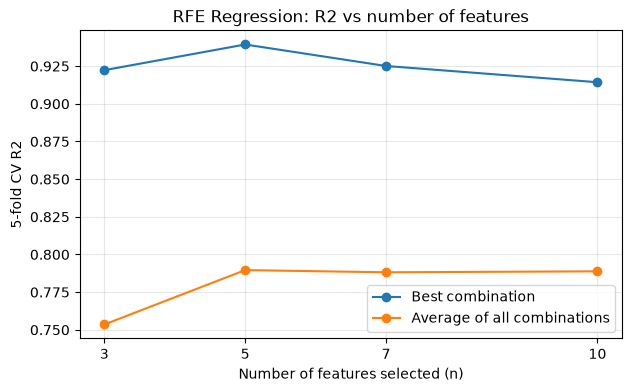

In [31]:
plt.figure(figsize=(7, 4))
best_per_n = cv_df.groupby('n_features')['CV_Mean'].max()
mean_per_n = cv_df.groupby('n_features')['CV_Mean'].mean()
plt.plot(best_per_n.index, best_per_n.values, marker='o', label='Best combination')
plt.plot(mean_per_n.index, mean_per_n.values, marker='o', label='Average of all combinations')
plt.xticks(n_list)
plt.xlabel('Number of features selected (n)')
plt.ylabel('5-fold CV R2')
plt.title('RFE Regression: R2 vs number of features')
plt.legend()
plt.grid(alpha=0.3)
plt.show()